This is a simple demo in the use of a GNN. There is a minimal dataset and GNN implementation included.

In [1]:
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np

In [2]:
import mplhep as mh
mh.style.use("CMS") 

In [3]:
# ===== ME0SegReco Setup =====
import sys
import site

user_site = site.USER_SITE
me0_src = '/eos/home-i01/k/kkeshav/SWAN_projects/me0_v2/ME0SegReco/src'

for path in [user_site, me0_src]:
    if path not in sys.path:
        sys.path.insert(0, path)

from me0.data.datasets.GNNDataset import GNNDataset
from me0.modules.gnn.model import HitGNN
print("✓ ME0SegReco loaded")

✓ ME0SegReco loaded


In [3]:
from me0.data.datasets.GNNDataset import GNNDataset
from me0.modules.gnn.model import HitGNN

ModuleNotFoundError: No module named 'me0'

In [5]:
dataset = GNNDataset("preprocessed_graph", d_strip_max=10, d_ieta_max=2, d_bx_max=1)

In [6]:
# Check GPU availability
print("CUDA available:", torch.cuda.is_available())
print("MPS available:", torch.mps.is_available())
#print("Current device:", device)
print("Model device:", next(model.parameters()).device)


CUDA available: True
MPS available: False


NameError: name 'model' is not defined

In [7]:
# Note, I changed this to be mps for testing on my laptop, you should use CUDA for any non-mac silicone devices
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device :{device}")
model = HitGNN(input_node_dim=5, edge_dim=5, hidden_dim=10, num_layers=6).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=0)

loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(75))
print(f"Model is on:{next(model.parameters()).device}")

Using device :cuda
Model is on:cuda:0


In [8]:
# A quick and dirty function to count the parameters of the model
def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

total_params = count_parameters(model)
print(f"Total parameters: {total_params}")

Total parameters: 4971


In [9]:
from torch_geometric.loader import DataLoader
from torch.utils.data import Subset

n_train = 10000
n_val = 10000

train_subset =  Subset(dataset, list(range(0, n_train)))
val_subset = Subset(dataset, list(range(n_train, n_train+n_val)))

train_loader = DataLoader(train_subset,  shuffle=True, drop_last=True, batch_size=100)
val_loader = DataLoader(val_subset, shuffle=False, drop_last=True, batch_size=100)


In [10]:
def train_loop(epoch, step, out_df):
    for batch in tqdm(train_loader):
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch)
        loss = loss_fn(out, batch.y.float().squeeze())
        loss.backward()
        optimizer.step()
        out_df.loc[len(out_df)] = [epoch, step, loss.item(), None]
        step += 1
    return step

In [11]:
def val_loop(epoch, step, out_df):
    groundtruth = []
    likelihood = []
    with torch.inference_mode():
        loss = 0
        for batch in tqdm(val_loader):
            batch = batch.to(device)
            out = model(batch)
            loss += loss_fn(out, batch.y.float().squeeze()).item()
            # Save predictions
            groundtruth += (batch.y.squeeze()==1).cpu().tolist()
            likelihood += nn.functional.sigmoid(out).cpu().tolist()
        groundtruth = np.array(groundtruth)
        likelihood = np.array(likelihood) 
        out_df.loc[len(out_df)] = [epoch, step, None, loss/len(val_loader)]
        return groundtruth, likelihood

In [12]:
out_df = pd.DataFrame(columns=['epoch', 'step', 'train_loss', 'val_loss'])

num_epoch = 5
step = 0
epoch = 0

groundtruth, likelihood = val_loop(epoch, step, out_df)

for epoch in range(num_epoch+1):
    step = train_loop(epoch, step, out_df)
    groundtruth, likelihood = val_loop(epoch, step, out_df)
    print(f"""
    Epoch {epoch}/{num_epoch}
        train_loss: {out_df[(out_df['epoch'] == epoch)]['train_loss'].dropna().mean()}
        val_loss: {out_df[(out_df['epoch'] == epoch)]['val_loss'].dropna().mean()}
    """) 

100%|██████████| 100/100 [00:01<00:00, 95.44it/s]



    Epoch 0/5
        train_loss: 1.205496746301651
        val_loss: 1.0601175451278686
    


100%|██████████| 100/100 [00:01<00:00, 93.67it/s]



    Epoch 1/5
        train_loss: 0.3753557713329792
        val_loss: 0.19731393903493882
    


100%|██████████| 100/100 [00:01<00:00, 96.71it/s]


...


    Epoch 3/5
        train_loss: 0.10259607296437025
        val_loss: 0.089248976893723
    


100%|██████████| 100/100 [00:01<00:00, 94.39it/s]



    Epoch 4/5
        train_loss: 0.0808054744452238
        val_loss: 0.07105396438390016
    


100%|██████████| 100/100 [00:01<00:00, 94.65it/s]


    Epoch 5/5
        train_loss: 0.07084648257121444
        val_loss: 0.06781127743422985
    


In [21]:
# ===== Comprehensive Dataset Statistics Analysis =====

import torch
import numpy as np
from tqdm import tqdm

print("="*70)
print("DATASET STATISTICS ANALYSIS")
print("="*70)

# ===== 1. FULL DATASET =====
print("\n[1] FULL DATASET")
print("-" * 70)
print(f"Dataset name: preprocessed_graph")
print(f"Total events in dataset: {len(dataset)}")

# Analyze full dataset
total_muon_hits = 0
total_background_hits = 0
total_hits = 0

print("\nAnalyzing all events in the dataset...")
for i in tqdm(range(len(dataset))):
    event = dataset[i]
    y = event.y.squeeze()
    
    muon_hits = (y == 1).sum().item()
    background_hits = (y == 0).sum().item()
    
    total_muon_hits += muon_hits
    total_background_hits += background_hits
    total_hits += len(y)

print(f"\nTotal hits: {total_hits:,}")
print(f"Total muon hits: {total_muon_hits:,}")
print(f"Total background hits: {total_background_hits:,}")
print(f"Signal fraction: {total_muon_hits/total_hits:.4f} ({100*total_muon_hits/total_hits:.2f}%)")
print(f"Background fraction: {total_background_hits/total_hits:.4f} ({100*total_background_hits/total_hits:.2f}%)")
print(f"Average hits per event: {total_hits/len(dataset):.1f}")
print(f"Imbalance ratio (background/signal): {total_background_hits/total_muon_hits:.1f}")

# ===== 2. TRAINING SET =====
print("\n" + "="*70)
print("[2] TRAINING SET")
print("-" * 70)
print(f"Training events: {n_train:,} (indices 0 to {n_train-1})")

train_muon_hits = 0
train_background_hits = 0
train_total_hits = 0

print("\nAnalyzing training events...")
for i in tqdm(range(0, n_train)):
    event = dataset[i]
    y = event.y.squeeze()
    
    muon_hits = (y == 1).sum().item()
    background_hits = (y == 0).sum().item()
    
    train_muon_hits += muon_hits
    train_background_hits += background_hits
    train_total_hits += len(y)

print(f"\nTotal hits: {train_total_hits:,}")
print(f"Total muon hits: {train_muon_hits:,}")
print(f"Total background hits: {train_background_hits:,}")
print(f"Signal fraction: {train_muon_hits/train_total_hits:.4f} ({100*train_muon_hits/train_total_hits:.2f}%)")
print(f"Background fraction: {train_background_hits/train_total_hits:.4f} ({100*train_background_hits/train_total_hits:.2f}%)")
print(f"Average hits per event: {train_total_hits/n_train:.1f}")
print(f"Imbalance ratio (background/signal): {train_background_hits/train_muon_hits:.1f}")

# ===== 3. VALIDATION SET =====
print("\n" + "="*70)
print("[3] VALIDATION SET")
print("-" * 70)
print(f"Validation events: {n_val:,} (indices {n_train} to {n_train+n_val-1})")

val_muon_hits = 0
val_background_hits = 0
val_total_hits = 0

print("\nAnalyzing validation events...")
for i in tqdm(range(n_train, n_train + n_val)):
    event = dataset[i]
    y = event.y.squeeze()
    
    muon_hits = (y == 1).sum().item()
    background_hits = (y == 0).sum().item()
    
    val_muon_hits += muon_hits
    val_background_hits += background_hits
    val_total_hits += len(y)

print(f"\nTotal hits: {val_total_hits:,}")
print(f"Total muon hits: {val_muon_hits:,}")
print(f"Total background hits: {val_background_hits:,}")
print(f"Signal fraction: {val_muon_hits/val_total_hits:.4f} ({100*val_muon_hits/val_total_hits:.2f}%)")
print(f"Background fraction: {val_background_hits/val_total_hits:.4f} ({100*val_background_hits/val_total_hits:.2f}%)")
print(f"Average hits per event: {val_total_hits/n_val:.1f}")
print(f"Imbalance ratio (background/signal): {val_background_hits/val_muon_hits:.1f}")

# ===== 4. COMPARISON TABLE =====
print("\n" + "="*70)
print("[4] SUMMARY COMPARISON")
print("="*70)
print(f"\n{'Metric':<30} {'Full Dataset':<20} {'Training':<20} {'Validation':<20}")
print("-" * 90)
print(f"{'Events':<30} {len(dataset):<20,} {n_train:<20,} {n_val:<20,}")
print(f"{'Total Hits':<30} {total_hits:<20,} {train_total_hits:<20,} {val_total_hits:<20,}")
print(f"{'Muon Hits':<30} {total_muon_hits:<20,} {train_muon_hits:<20,} {val_muon_hits:<20,}")
print(f"{'Background Hits':<30} {total_background_hits:<20,} {train_background_hits:<20,} {val_background_hits:<20,}")
print(f"{'Signal Fraction (%)':<30} {100*total_muon_hits/total_hits:<20.2f} {100*train_muon_hits/train_total_hits:<20.2f} {100*val_muon_hits/val_total_hits:<20.2f}")
print(f"{'Avg Hits/Event':<30} {total_hits/len(dataset):<20.1f} {train_total_hits/n_train:<20.1f} {val_total_hits/n_val:<20.1f}")
print(f"{'Imbalance Ratio':<30} {total_background_hits/total_muon_hits:<20.1f} {train_background_hits/train_muon_hits:<20.1f} {val_background_hits/val_muon_hits:<20.1f}")

print("\n" + "="*70)
print("ANALYSIS COMPLETE")
print("="*70)

DATASET STATISTICS ANALYSIS

[1] FULL DATASET
----------------------------------------------------------------------
Dataset name: preprocessed_graph
Total events in dataset: 35430

Analyzing all events in the dataset...


100%|██████████| 35430/35430 [00:02<00:00, 17302.16it/s]



Total hits: 3,105,283
Total muon hits: 40,949
Total background hits: 3,064,334
Signal fraction: 0.0132 (1.32%)
Background fraction: 0.9868 (98.68%)
Average hits per event: 87.6
Imbalance ratio (background/signal): 74.8

[2] TRAINING SET
----------------------------------------------------------------------
Training events: 10,000 (indices 0 to 9999)

Analyzing training events...


100%|██████████| 10000/10000 [00:00<00:00, 15464.33it/s]



Total hits: 876,916
Total muon hits: 11,578
Total background hits: 865,338
Signal fraction: 0.0132 (1.32%)
Background fraction: 0.9868 (98.68%)
Average hits per event: 87.7
Imbalance ratio (background/signal): 74.7

[3] VALIDATION SET
----------------------------------------------------------------------
Validation events: 10,000 (indices 10000 to 19999)

Analyzing validation events...


100%|██████████| 10000/10000 [00:00<00:00, 17851.28it/s]


Total hits: 877,789
Total muon hits: 11,731
Total background hits: 866,058
Signal fraction: 0.0134 (1.34%)
Background fraction: 0.9866 (98.66%)
Average hits per event: 87.8
Imbalance ratio (background/signal): 73.8

[4] SUMMARY COMPARISON

Metric                         Full Dataset         Training             Validation          
------------------------------------------------------------------------------------------
Events                         35,430               10,000               10,000              
Total Hits                     3,105,283            876,916              877,789             
Muon Hits                      40,949               11,578               11,731              
Background Hits                3,064,334            865,338              866,058             
Signal Fraction (%)            1.32                 1.32                 1.34                
Avg Hits/Event                 87.6                 87.7                 87.8                
Imbalance 

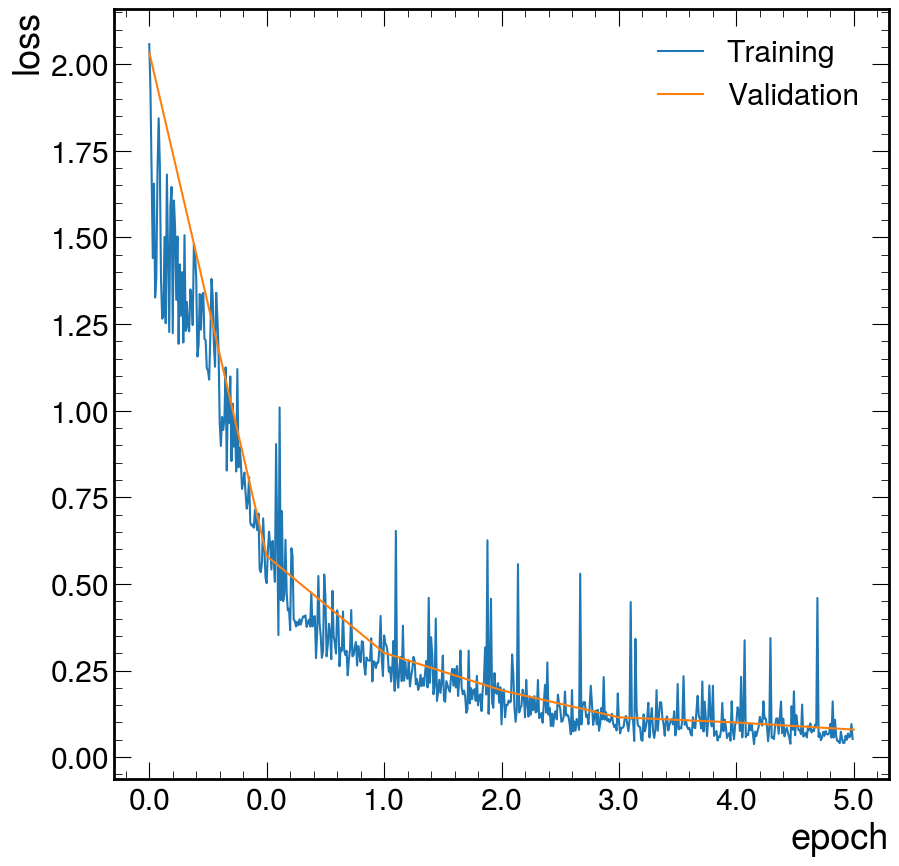

In [16]:

plt.plot(out_df[out_df['train_loss'].notna()]['step'], out_df['train_loss'].dropna(), label='Training')
plt.plot(out_df[out_df['val_loss'].notna()]['step'], out_df['val_loss'].dropna(), label='Validation')
plt.xticks(ticks=out_df[out_df['val_loss'].notna()]['step'], labels=out_df[out_df['val_loss'].notna()]['epoch'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()

(0.001, 30.0)

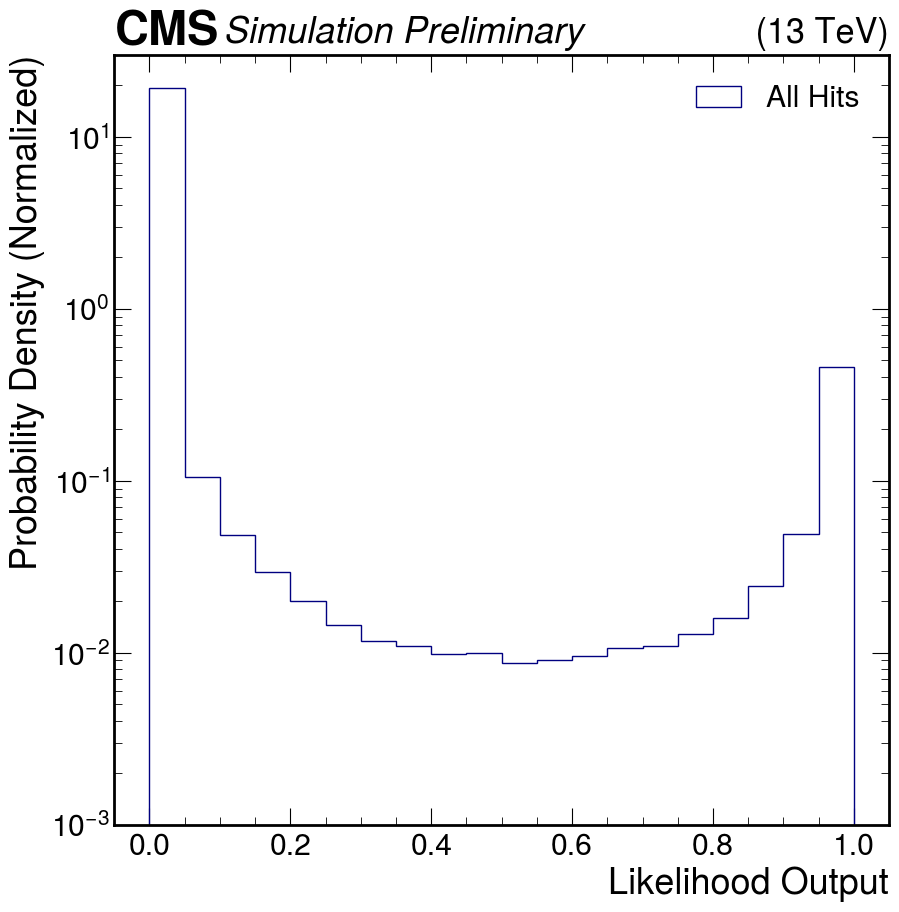

In [15]:
# Now, you have two arrays of data.
# Likelihood contains the model's output probability for each hit
bins = np.linspace(0, 1, 21)
fig, ax = plt.subplots(figsize=(10, 10))
plt.hist(
        likelihood, 
        bins=bins, 
        density=True, 
        label='All Hits',
        histtype='step',
        color='navy'
    )
plt.yscale('log')
plt.legend()
plt.xlabel('Likelihood Output')
plt.ylabel('Probability Density (Normalized)')
mh.cms.label(loc=0, label="Preliminary", data=False) 

plt.ylim(1e-3, 3e1) 



/cvmfs/sft.cern.ch/lcg/views/LCG_108_cuda/x86_64-el9-gcc13-opt/lib/python3.12/site-packages/matplotlib/axes/_axes.py:7129: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  m, bins = np.histogram(x[i], bins, weights=w[i], **hist_kwargs)


(0.001, 30.0)

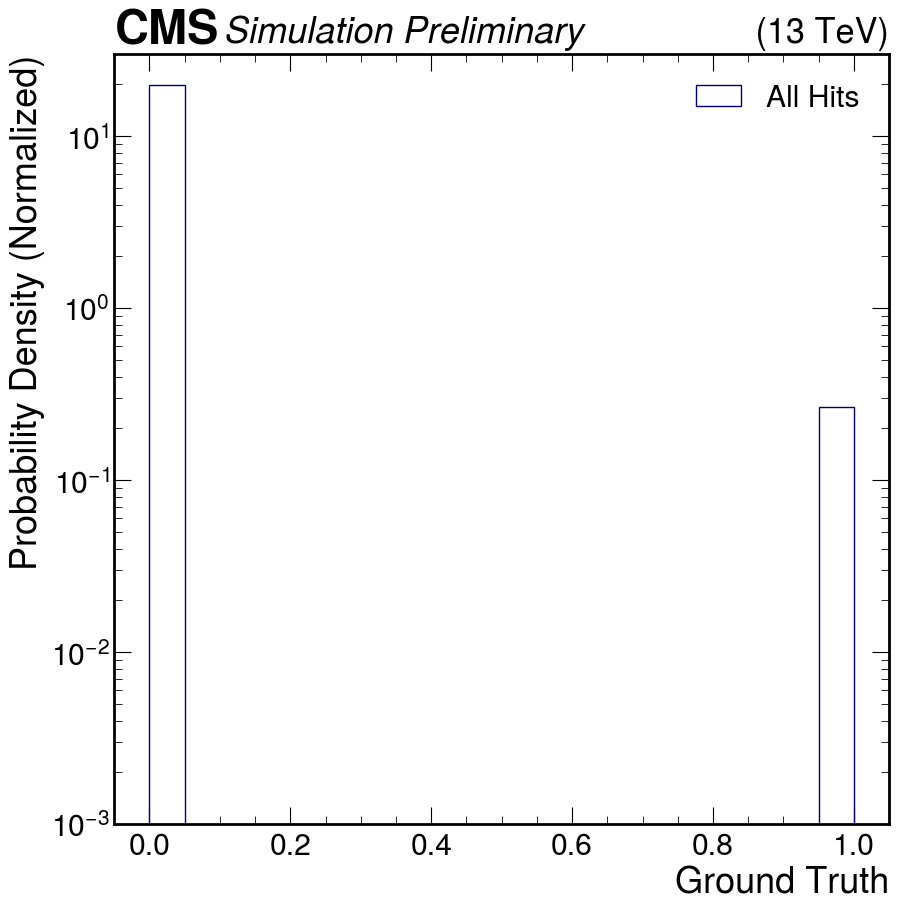

In [17]:
# Groundtruth contains the mc truth of if the hit is a muon or not. 
bins = np.linspace(0, 1, 21)
fig, ax = plt.subplots(figsize=(10, 10))
plt.hist(
        groundtruth, 
        bins=bins, 
        density=True, 
    
        label='All Hits',
        histtype='step',
        color='navy'
    )
plt.yscale('log')
plt.legend()
plt.xlabel('Ground Truth')
plt.ylabel('Probability Density (Normalized)')
mh.cms.label(loc=0, label="Preliminary", data=False) 

plt.ylim(1e-3, 3e1) 



In [18]:
# And here is a simple bit of code to compute the tpr/fpr for a certain cut value
# 
def compute_tpr_fpr(groundtruth, likelihood, cutoff):
    mask = groundtruth == 1
    n_muons = mask.sum()
    n_non_muons = (1-mask).sum()

    tp = (likelihood[groundtruth] >= cutoff).sum()
    tpr = tp/n_muons

    fp = (likelihood[~groundtruth] >= cutoff).sum()
    fpr = fp / n_non_muons
    return float(tpr), float(fpr)
# Compute the true positive rate and false positve rate for a cutoff of .5 in the likelihood
compute_tpr_fpr(groundtruth, likelihood, .5)

(0.992754240900179, 0.0154631675938563)

In [19]:
# Compute tpr and fpr for various cutoffs
cutoffs = np.linspace(0, 1, 1000)
tprs = []
fprs = []
for cutoff in cutoffs:
    tpr, fpr = compute_tpr_fpr(groundtruth, likelihood, cutoff)
    tprs.append(tpr)
    fprs.append(fpr)

tprs = np.array(tprs)
fprs = np.array(fprs)

In [20]:
#This function allows you to compute the fpr at a target tpr
def fpr_at_tpr(target_tpr, tprs, fprs, cutoffs):
    # Ensure tprs are sorted increasingly for interpolation
    sort_idx = np.argsort(tprs)
    tprs_sorted = tprs[sort_idx]
    fprs_sorted = fprs[sort_idx]
    cutoffs_sorted = cutoffs[sort_idx]

    # Interpolate FPR and Cutoff
    interpolated_fpr = np.interp(target_tpr, tprs_sorted, fprs_sorted)
    interpolated_cutoff = np.interp(target_tpr, tprs_sorted, cutoffs_sorted)

    return float(interpolated_cutoff), float(interpolated_fpr)

In [20]:
fpr_at_tpr(.9, tprs, fprs, cutoffs), 
fpr_at_tpr(.95, tprs, fprs, cutoffs), fpr_at_tpr(.995, tprs, fprs, cutoffs)

((0.9944439810180551, 0.0038211863194860876),
 (0.988555660924082, 0.005520134423961636),
 (0.9165715715715714, 0.011715912791060185))

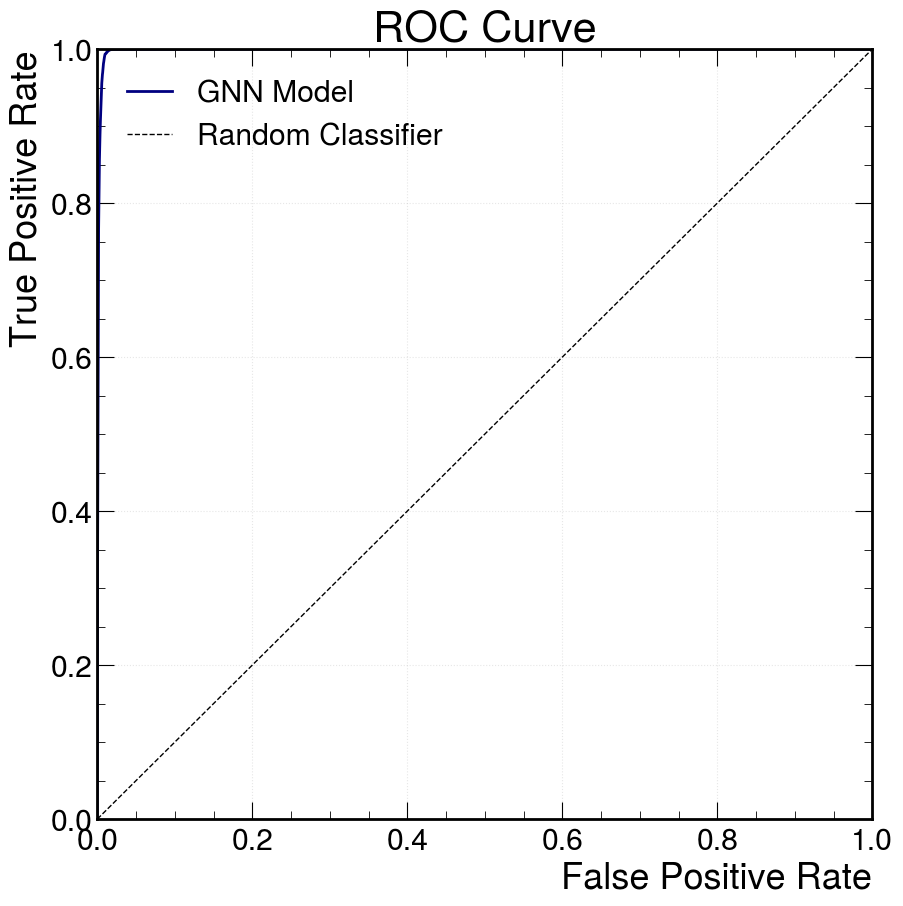

In [21]:
# Plot ROC curve
fig, ax = plt.subplots(figsize=(10, 10))
plt.plot(fprs, tprs, linewidth
         =2, color='navy', label='GNN Model')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')  # diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True, alpha=0.3)
#mh.cms.label(loc=0, label="Preliminary", data=False)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.show()

In [21]:
# Zoomed ROC curve (low FPR region)
fig, ax = plt.subplots(figsize=(10, 10))
plt.plot(fprs, tprs, line
         width=2, color='navy', label='GNN Model')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Zoomed)')
plt.legend()
plt.grid(True, alpha=0.3)
#mh.cms.label(loc=0, label="Preliminary", data=False)
plt.xlim(0, 0.05)  # Zoom to low FPR
plt.ylim(0.8, 1.0)  # High TPR region
plt.show()

SyntaxError: invalid syntax. Perhaps you forgot a comma? (2628721158.py, line 3)

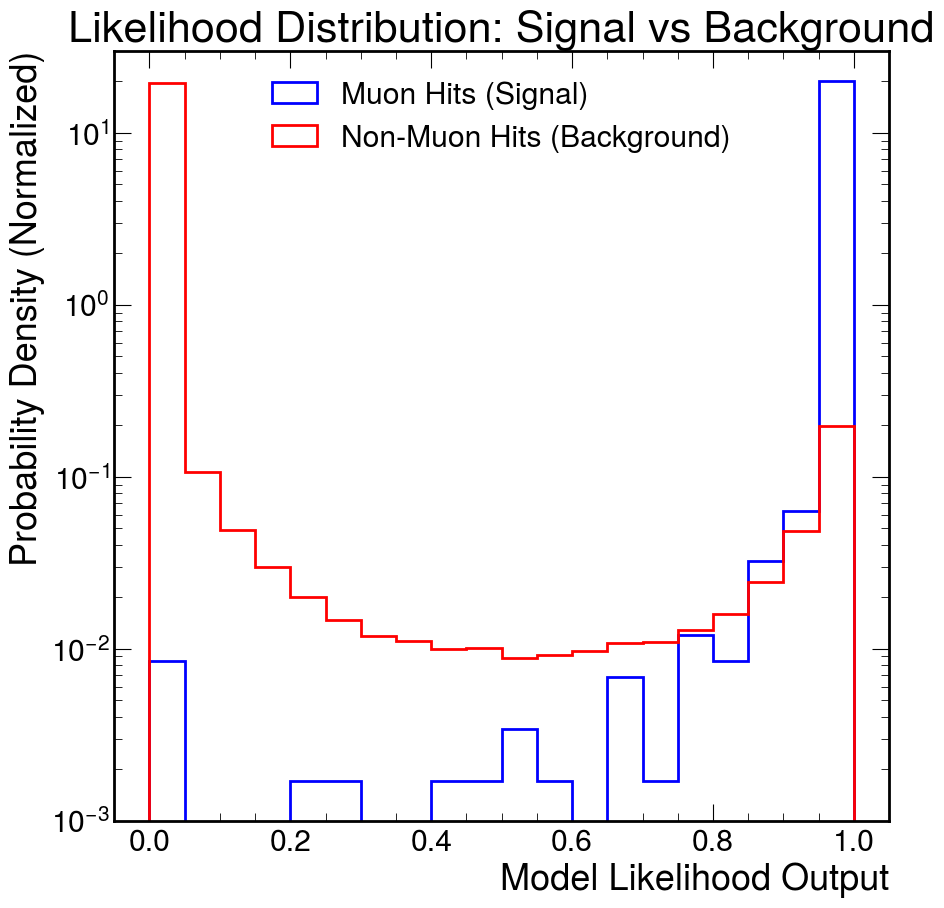

In [23]:
# Compare likelihood for muon hits vs non-muon hits
bins = np.linspace(0, 1, 21)
fig, ax = plt.subplots(figsize=(10, 10))

# Muon hits (signal)
plt.hist(
    likelihood[groundtruth == 1], 
    bins=bins, 
    density=True, 
    label='Muon Hits (Signal)',
    histtype='step',
    color='blue',
    linewidth=2
)

# Non-muon hits (background)
plt.hist(
    likelihood[groundtruth == 0], 
    bins=bins, 
    density=True, 
    label='Non-Muon Hits (Background)',
    histtype='step',
    color='red',
    linewidth=2
)

plt.yscale('log')
plt.legend()
plt.xlabel('Model Likelihood Output')
plt.ylabel('Probability Density (Normalized)')
plt.title('Likelihood Distribution: Signal vs Background')
#mh.cms.label(loc=0, label="Preliminary", data=False)
plt.ylim(1e-3, 3e1)
plt.show()

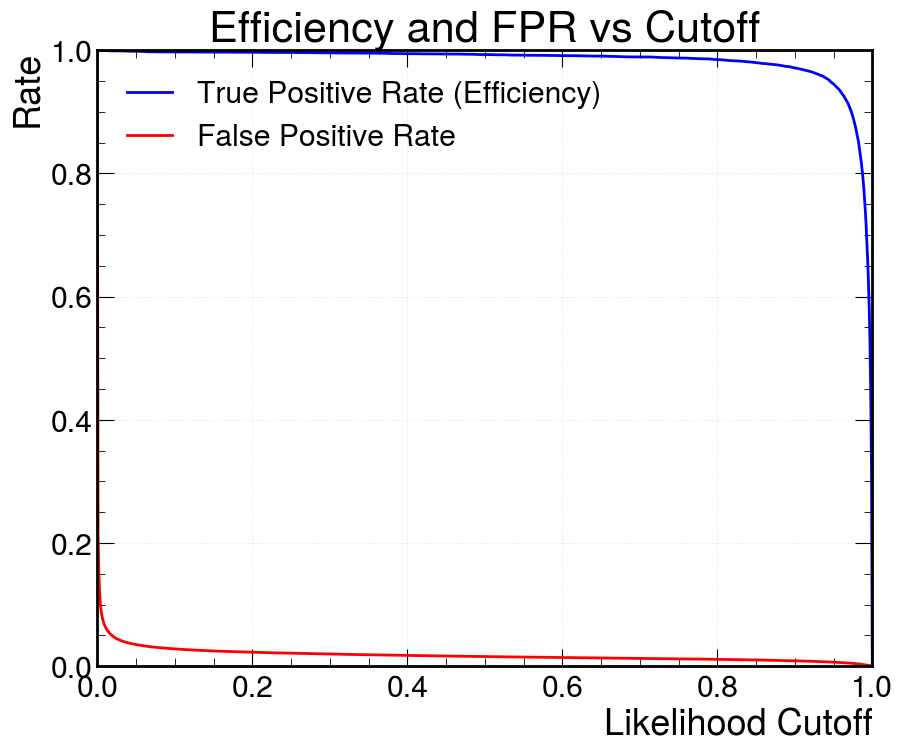

In [22]:
# Plot TPR and FPR vs cutoff value
fig, ax = plt.subplots(figsize=(10, 8))
plt.plot(cutoffs, tprs, label='True Positive Rate (Efficiency)', color='blue', linewidth=2)
plt.plot(cutoffs, fprs, label='False Positive Rate', color='red', linewidth=2)
plt.xlabel('Likelihood Cutoff')
plt.ylabel('Rate')
plt.title('Efficiency and FPR vs Cutoff')
plt.legend()
plt.grid(True, alpha=0.3)
#mh.cms.label(loc=0, label="Preliminary", data=False)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.show()

In [23]:
# Print some key metrics
print("=== Model Performance Summary ===")
print(f"At 90% TPR: FPR = {fpr_at_tpr(.9, tprs, fprs, cutoffs)[1]:.4f}, Cutoff = {fpr_at_tpr(.9, tprs, fprs, cutoffs)[0]:.4f}")
print(f"At 95% TPR: FPR = {fpr_at_tpr(.95, tprs, fprs, cutoffs)[1]:.4f}, Cutoff = {fpr_at_tpr(.95, tprs, fprs, cutoffs)[0]:.4f}")
print(f"At 99.5% TPR: FPR = {fpr_at_tpr(.995, tprs, fprs, cutoffs)[1]:.4f}, Cutoff = {fpr_at_tpr(.995, tprs, fprs, cutoffs)[0]:.4f}")
print(f"\nTotal muon hits: {(groundtruth == 1).sum()}")
print(f"Total non-muon hits: {(groundtruth == 0).sum()}")
print(f"Signal fraction: {(groundtruth == 1).sum() / len(groundtruth):.4f}")

=== Model Performance Summary ===
At 90% TPR: FPR = 0.0046, Cutoff = 0.9730
At 95% TPR: FPR = 0.0067, Cutoff = 0.9452
At 99.5% TPR: FPR = 0.0183, Cutoff = 0.3510

Total muon hits: 11731
Total non-muon hits: 866058
Signal fraction: 0.0134


In [24]:
# Collect node features from the dataset
all_bx = []
all_ieta = []
all_layer = []
all_strip = []
all_charge = []

print("Extracting node features from dataset...")
# Sample from first 1000 graphs to make it faster
for i in tqdm(range(len(dataset))):
    graph = dataset[i]
    # Node features are: [bx, iEta, layer, strip, charge]
    all_bx.append(graph.x[:, 0].numpy())
    all_ieta.append(graph.x[:, 1].numpy())
    all_layer.append(graph.x[:, 2].numpy())
    all_strip.append(graph.x[:, 3].numpy())
    all_charge.append(graph.x[:, 4].numpy())

# Flatten lists
all_bx = np.concatenate(all_bx)
all_ieta = np.concatenate(all_ieta)
all_layer = np.concatenate(all_layer)
all_strip = np.concatenate(all_strip)
all_charge = np.concatenate(all_charge)

print(f"Total hits collected: {len(all_bx)}")

Extracting node features from dataset...


100%|██████████| 35430/35430 [00:03<00:00, 9046.75it/s] 

Total hits collected: 3105283


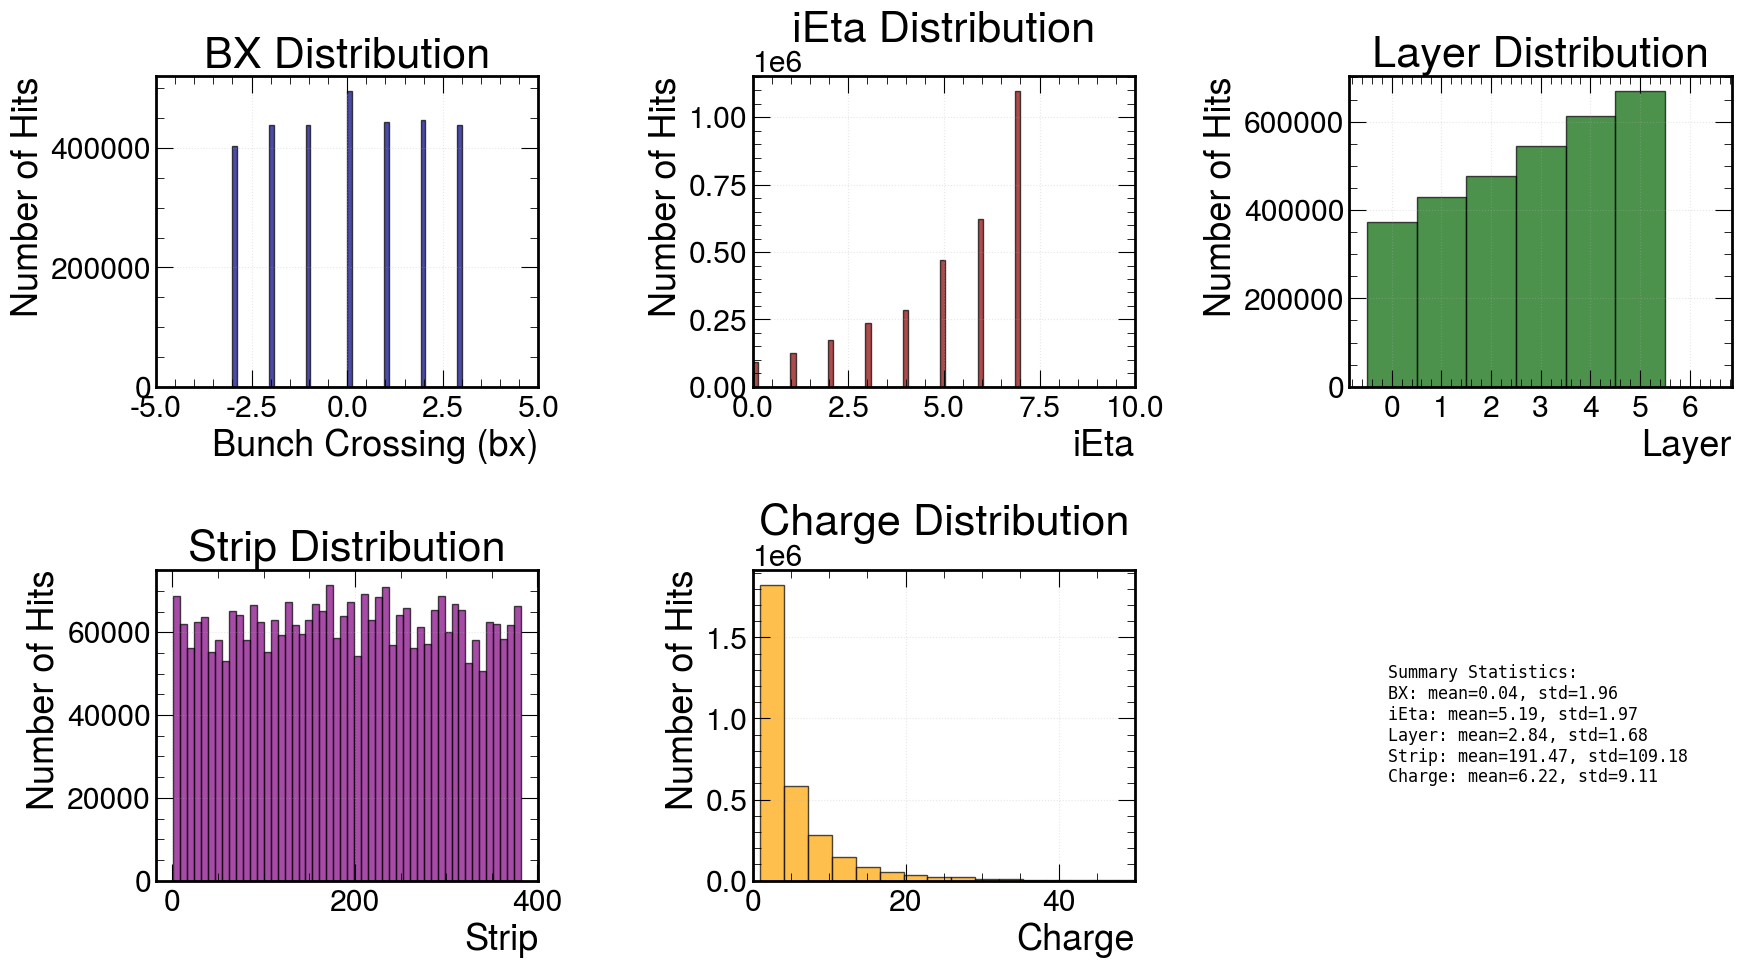

✅ Node feature histograms saved!


In [44]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))



# BX (Bunch Crossing)
bx_vals = np.array(all_bx)
bx_min, bx_max = bx_vals.min(), bx_vals.max()
bins = np.arange(bx_min -0.5, bx_max +1.5, 1)
axes[0, 0].hist(all_bx, bins=50, color='navy', alpha=0.7, edgecolor='black')
axes[0, 0].set_xlim(-5,5)
axes[0, 0].set_xlabel('Bunch Crossing (bx)')
axes[0, 0].set_ylabel('Number of Hits')
axes[0, 0].set_title('BX Distribution')
axes[0, 0].grid(True, alpha=0.3)

# iEta
axes[0, 1].hist(all_ieta, bins=50, color='darkred', alpha=0.7, edgecolor='black')
axes[0, 1].set_xlim(0,10)
axes[0, 1].set_xlabel('iEta')
axes[0, 1].set_ylabel('Number of Hits')
axes[0, 1].set_title('iEta Distribution')
axes[0, 1].grid(True, alpha=0.3)

# Layer
axes[0, 2].hist(all_layer, bins=np.arange(-0.5, 7.5, 1), color='darkgreen', alpha=0.7, edgecolor='black')
axes[0, 2].set_xlabel('Layer')
axes[0, 2].set_ylabel('Number of Hits')
axes[0, 2].set_title('Layer Distribution')
axes[0, 2].set_xticks(range(7))
axes[0, 2].grid(True, alpha=0.3)

# Strip
axes[1, 0].hist(all_strip, bins=50, color='purple', alpha=0.7, edgecolor='black')
axes[1, 0].set_xlabel('Strip')
axes[1, 0].set_ylabel('Number of Hits')
axes[1, 0].set_title('Strip Distribution')
axes[1, 0].grid(True, alpha=0.3)

# Charge
axes[1, 1].hist(all_charge, bins=100, color='orange', alpha=0.7, edgecolor='black')
axes[1, 1].set_xlim(0,50)
axes[1, 1].set_xlabel('Charge')
axes[1, 1].set_ylabel('Number of Hits')
axes[1, 1].set_title('Charge Distribution')
axes[1, 1].grid(True, alpha=0.3)

# Summary statistics
summary_text = f"""
Summary Statistics:
BX: mean={all_bx.mean():.2f}, std={all_bx.std():.2f}
iEta: mean={all_ieta.mean():.2f}, std={all_ieta.std():.2f}
Layer: mean={all_layer.mean():.2f}, std={all_layer.std():.2f}
Strip: mean={all_strip.mean():.2f}, std={all_strip.std():.2f}
Charge: mean={all_charge.mean():.2f}, std={all_charge.std():.2f}
"""
axes[1, 2].text(0.1, 0.5, summary_text, fontsize=12, verticalalignment='center', family='monospace')
axes[1, 2].axis('off')

plt.tight_layout()
#mh.cms.label(loc=0, label="Preliminary", data=False, ax=axes[0, 0])
plt.savefig('node_features_histograms.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Node feature histograms saved!")

In [27]:
# Check dataset information
print("=== Dataset Information ===")
print(f"Total number of graphs (events): {len(dataset)}")
print(f"Total number of samples: {len(dataset)}")

# Look at one example
sample_graph = dataset[0]
print(f"\n=== Example Graph (Event 0) ===")
print(f"Number of nodes (hits): {sample_graph.x.shape[0]}")
print(f"Number of edges: {sample_graph.edge_index.shape[1]}")
print(f"Node features shape: {sample_graph.x.shape}")
print(f"Edge features shape: {sample_graph.edge_attr.shape}")

# Check a few more
print(f"\n=== Sample of Graph Sizes ===")
for i in range(5):
    g = dataset[i]
    print(f"Graph {i}: {g.x.shape[0]} hits")


=== Dataset Information ===
Total number of graphs (events): 35430
Total number of samples: 35430

=== Example Graph (Event 0) ===
Number of nodes (hits): 65
Number of edges: 140
Node features shape: torch.Size([65, 5])
Edge features shape: torch.Size([140, 5])

=== Sample of Graph Sizes ===
Graph 0: 65 hits
Graph 1: 90 hits
Graph 2: 112 hits
Graph 3: 79 hits
Graph 4: 73 hits


In [54]:
# Store results from multiple training runs
all_results = []

num_runs = 3  # Train 3 different models

for run in range(num_runs):
    print(f"\n{'='*50}")
    print(f"🚀 Training Run {run + 1} / {num_runs}")
    print(f"{'='*50}\n")
    
    # Create new model with same architecture
    model = HitGNN(input_node_dim=5, edge_dim=5, hidden_dim=10, num_layers=6).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=0)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(75).to(device))
    
    # Training
    out_df = pd.DataFrame(columns=['epoch', 'step', 'train_loss', 'val_loss'])
    num_epoch = 5
    step = 0
    
    # Initial validation
    groundtruth, likelihood = val_loop(0, step, out_df)
    
    # Train
    for epoch in range(num_epoch + 1):
        step = train_loop(epoch, step, out_df)
        groundtruth, likelihood = val_loop(epoch, step, out_df)
        print(f"Epoch {epoch}/{num_epoch} - train_loss: {out_df[(out_df['epoch'] == epoch)]['train_loss'].dropna().mean():.4f}, val_loss: {out_df[(out_df['epoch'] == epoch)]['val_loss'].dropna().mean():.4f}")
    
    # Evaluate
    cutoffs = np.linspace(0, 1, 1000)
    tprs = []
    fprs = []
    for cutoff in cutoffs:
        tpr, fpr = compute_tpr_fpr(groundtruth, likelihood, cutoff)
        tprs.append(tpr)
        fprs.append(fpr)
    tprs = np.array(tprs)
    fprs = np.array(fprs)
    
    # Store results
    fpr_90 = fpr_at_tpr(0.90, tprs, fprs, cutoffs)[1]
    fpr_95 = fpr_at_tpr(0.95, tprs, fprs, cutoffs)[1]
    fpr_995 = fpr_at_tpr(0.995, tprs, fprs, cutoffs)[1]
    
    all_results.append({
    'run': run + 1,
    'tprs': tprs,
    'fprs': fprs,
    'fpr_at_90': fpr_90,
    'fpr_at_95': fpr_95,
    'fpr_at_995': fpr_995,
    'final_train_loss': out_df['train_loss'].dropna().
        iloc[-1],
    'final_val_loss': out_df['val_loss'].dropna().iloc[-1],
    'groundtruth': groundtruth,    # store for plotting likelihoods
    'likelihood': likelihood       # store likelihoods
})

    print(f"\n✅ Run {run + 1} Complete!")
    print(f"   FPR at 90% TPR: {fpr_90:.4f}")
    print(f"   FPR at 95% TPR: {fpr_95:.4f}")
    print(f"   FPR at 99.5% TPR: {fpr_995:.4f}")

print(f"\n{'='*50}")
print("🎉 All training runs complete!")
print(f"{'='*50}")


🚀 Training Run 1 / 3



100%|██████████| 100/100 [00:01<00:00, 93.27it/s]


Epoch 0/5 - train_loss: 2.9444, val_loss: 6.3690


100%|██████████| 100/100 [00:01<00:00, 94.04it/s]


Epoch 1/5 - train_loss: 0.7331, val_loss: 0.4011


...

Epoch 3/5 - train_loss: 0.0652, val_loss: 0.0691


100%|██████████| 100/100 [00:01<00:00, 96.97it/s]


Epoch 4/5 - train_loss: 0.0629, val_loss: 0.0608


100%|██████████| 100/100 [00:01<00:00, 96.50it/s]


Epoch 5/5 - train_loss: 0.0549, val_loss: 0.0499

✅ Run 3 Complete!
   FPR at 90% TPR: 0.0025
   FPR at 95% TPR: 0.0037
   FPR at 99.5% TPR: 0.0094

🎉 All training runs complete!


In [46]:
# Compare performance across runs
print("📊 Performance Comparison Across Runs:\n")
print(f"{'Run':<6} {'FPR@90%TPR':<15} {'FPR@95%TPR':<15} {'FPR@99.5%TPR':<15}")
print("-" * 60)

for result in all_results:
    print(f"{result['run']:<6} {result['fpr_at_90']:<15.4f} {result['fpr_at_95']:<15.4f} {result['fpr_at_995']:<15.4f}")

# Calculate statistics
fpr_90_values = [r['fpr_at_90'] for r in all_results]
fpr_95_values = [r['fpr_at_95'] for r in all_results]
fpr_995_values = [r['fpr_at_995'] for r in all_results]

print("\n📈 Variation Statistics:")
print(f"FPR at 90% TPR:  mean={np.mean(fpr_90_values):.4f}, std={np.std(fpr_90_values):.4f}")
print(f"FPR at 95% TPR:  mean={np.mean(fpr_95_values):.4f}, std={np.std(fpr_95_values):.4f}")
print(f"FPR at 99.5% TPR: mean={np.mean(fpr_995_values):.4f}, std={np.std(fpr_995_values):.4f}")


📊 Performance Comparison Across Runs:

Run    FPR@90%TPR      FPR@95%TPR      FPR@99.5%TPR   
------------------------------------------------------------
1      0.0041          0.0057          0.0131         
2      0.0039          0.0060          0.0177         
3      0.0028          0.0039          0.0107         

📈 Variation Statistics:
FPR at 90% TPR:  mean=0.0036, std=0.0006
FPR at 95% TPR:  mean=0.0052, std=0.0009
FPR at 99.5% TPR: mean=0.0138, std=0.0029


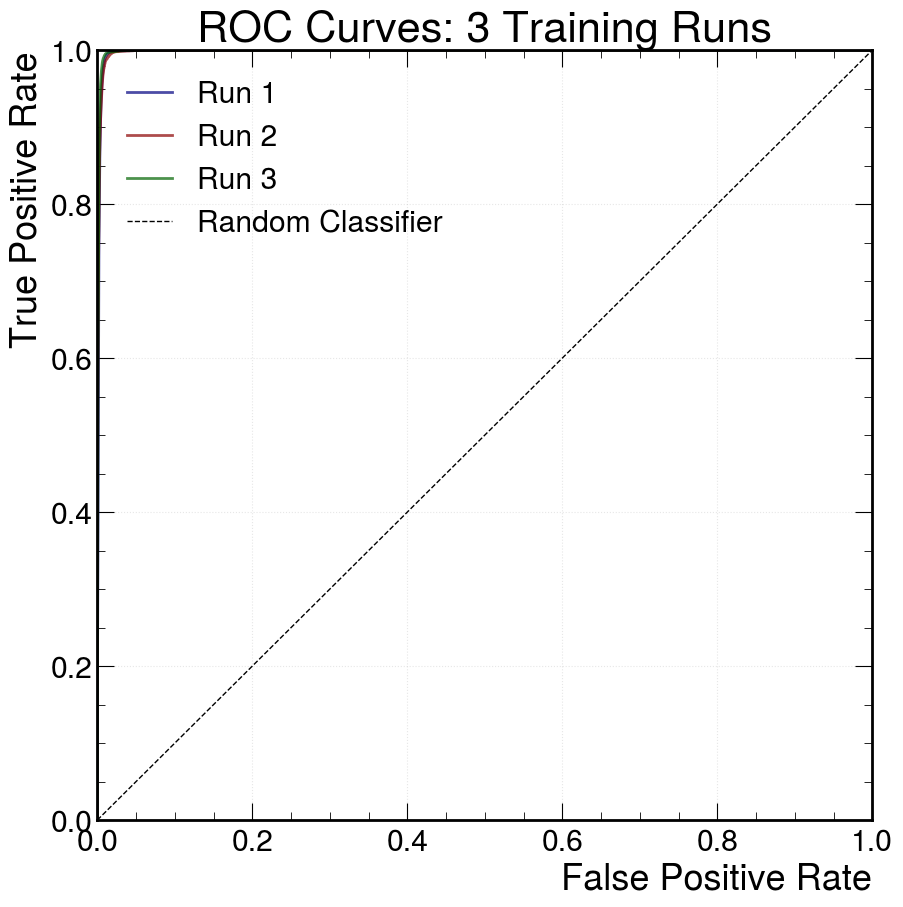

✅ ROC comparison plot saved!


In [52]:
# Plot all ROC curves together
fig, ax = plt.subplots(figsize=(10, 10))

colors = ['navy', 'darkred', 'darkgreen', 'purple', 'orange']

for i, result in enumerate(all_results):
    plt.plot(result['fprs'], result['tprs'], 
             linewidth=2, 
             color=colors[i], 
             label=f'Run {result["run"]}',
             alpha=0.7)

# Diagonal line
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curves: {num_runs} Training Runs')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 1)
plt.ylim(0, 1)
#mh.cms.label(loc=0, label="Preliminary", data=False)
plt.savefig('roc_comparison_multiple_runs.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ ROC comparison plot saved!")

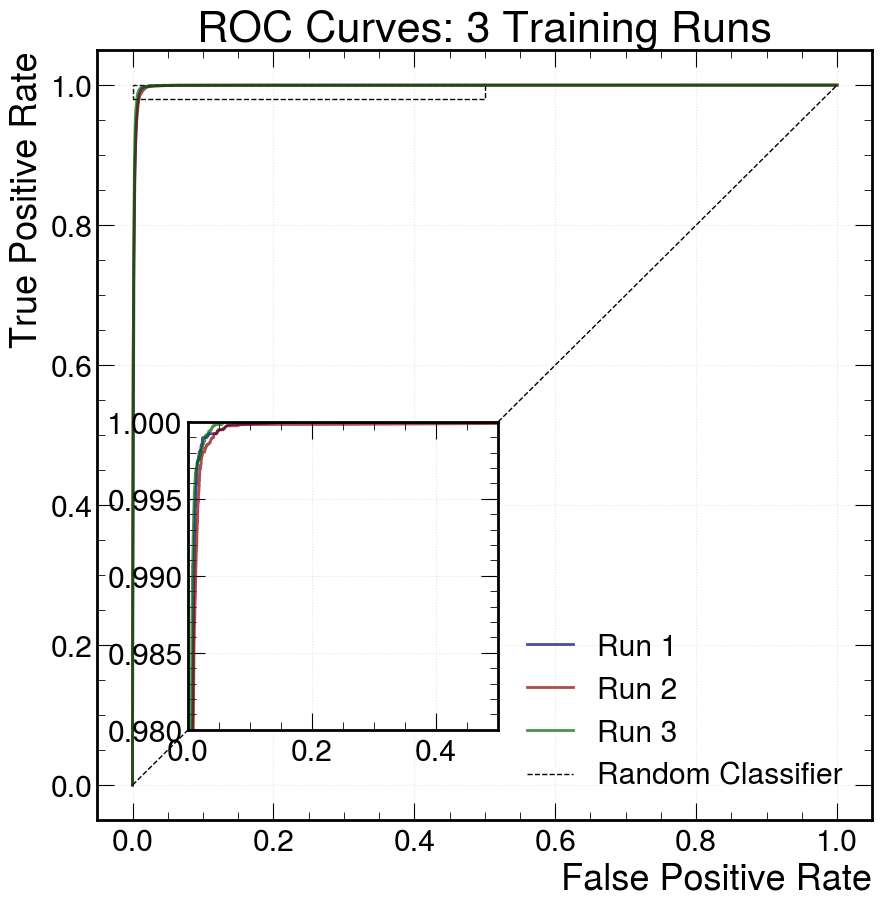

✅ Zoomed ROC comparison plot saved!


In [53]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Main plot
fig, ax = plt.subplots(figsize=(10, 10))

colors = ['navy', 'darkred', 'darkgreen', 'purple', 'orange']

for i, result in enumerate(all_results):
    ax.plot(result['fprs'], result['tprs'], 
            linewidth=2, 
            color=colors[i], 
            label=f'Run {result["run"]}',
            alpha=0.7)

# Diagonal line
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title(f'ROC Curves: {num_runs} Training Runs')
ax.legend()
ax.grid(True, alpha=0.3)

# Zoom-in inset (top-left corner)
# Adjust xlim_zoom and ylim_zoom as needed
xlim_zoom = (0, 0.5)
ylim_zoom = (0.98, 1.0)

axins = inset_axes(ax, width="40%", height="40%", loc='lower left', borderpad=3)
for i, result in enumerate(all_results):
    axins.plot(result['fprs'], result['tprs'], 
               linewidth=2, 
               color=colors[i], 
               alpha=0.7)

axins.plot([0, 1], [0, 1], 'k--', linewidth=1)
axins.set_xlim(*xlim_zoom)
axins.set_ylim(*ylim_zoom)
axins.grid(True, alpha=0.3)

# Optional: add a rectangle on the main plot to show the zoomed area
from matplotlib.patches import Rectangle
rect = Rectangle((xlim_zoom[0], ylim_zoom[0]),
                 xlim_zoom[1]-xlim_zoom[0],
                 ylim_zoom[1]-ylim_zoom[0],
                 linewidth=1, edgecolor='black', facecolor='none', linestyle='--')
ax.add_patch(rect)

# CMS label
#mh.cms.label(loc=0, label="Preliminary", data=False)

# Save figure
plt.savefig('roc_comparison_multiple_runs_zoomed.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Zoomed ROC comparison plot saved!")


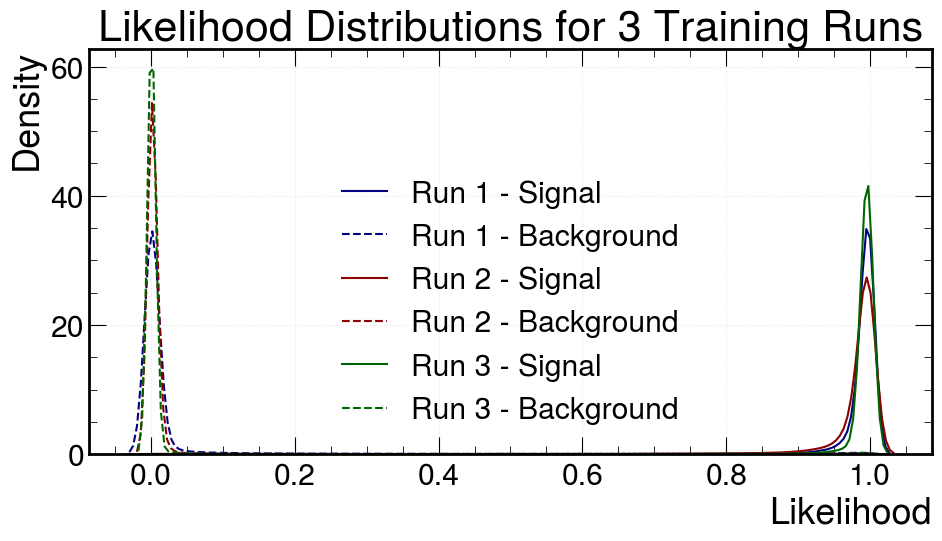

In [55]:
import seaborn as sns

plt.figure(figsize=(10,6))

colors = ['navy', 'darkred', 'darkgreen']

for i, result in enumerate(all_results):
    # likelihood of signal (1) and background (0)
    signal_lh = result['likelihood'][result['groundtruth'] == 1]
    background_lh = result['likelihood'][result['groundtruth'] == 0]
    
    # Plot distributions
    sns.kdeplot(signal_lh, color=colors[i], linestyle='-', label=f'Run {result["run"]} - Signal')
    sns.kdeplot(background_lh, color=colors[i], linestyle='--', label=f'Run {result["run"]} - Background')

plt.xlabel('Likelihood')
plt.ylabel('Density')
plt.title('Likelihood Distributions for 3 Training Runs')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('likelihood_distributions.png', dpi=300)
plt.show()


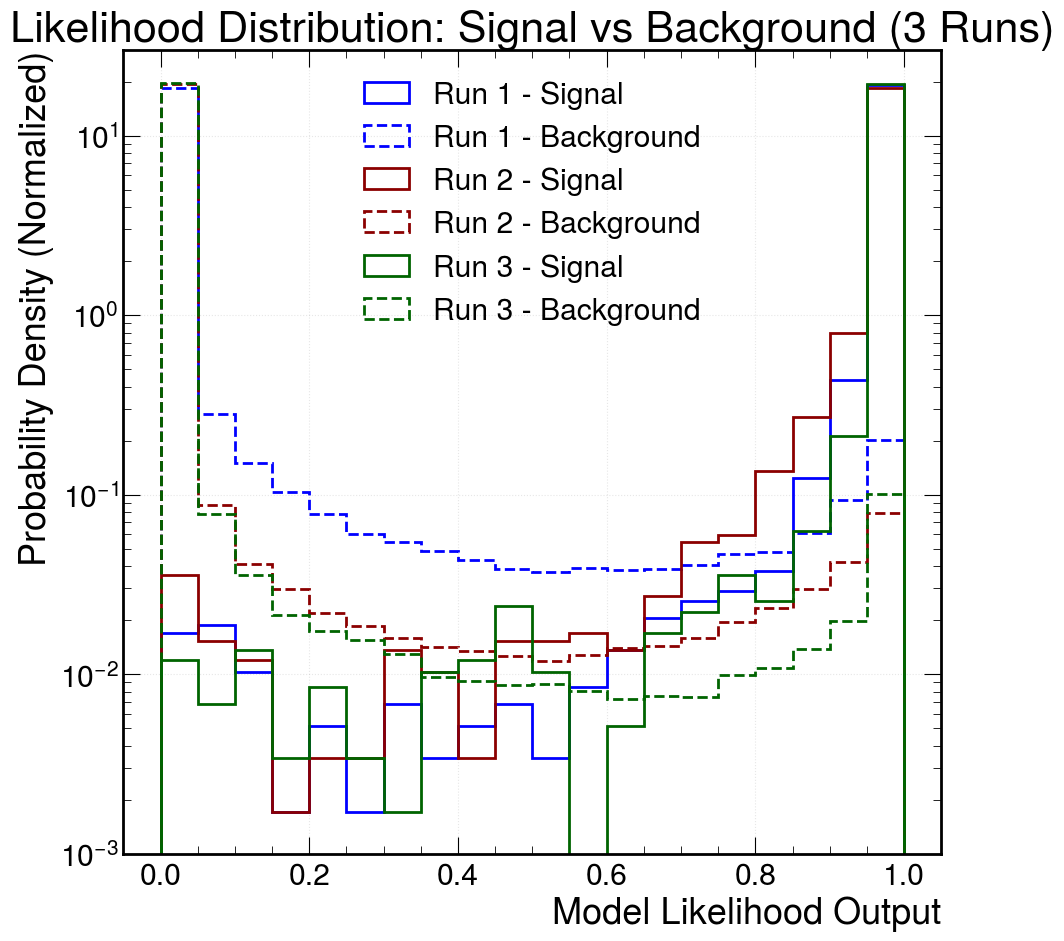

In [56]:
import numpy as np
import matplotlib.pyplot as plt

# Define bins
bins = np.linspace(0, 1, 21)
colors = ['blue', 'darkred', 'darkgreen']

fig, ax = plt.subplots(figsize=(10, 10))

for i, result in enumerate(all_results):
    # Signal (Muon hits)
    plt.hist(
        result['likelihood'][result['groundtruth'] == 1],
        bins=bins,
        density=True,
        histtype='step',
        color=colors[i],
        linewidth=2,
        label=f'Run {result["run"]} - Signal'
    )
    
    # Background (Non-muon hits)
    plt.hist(
        result['likelihood'][result['groundtruth'] == 0],
        bins=bins,
        density=True,
        histtype='step',
        color=colors[i],
        linewidth=2,
        linestyle='--',
        label=f'Run {result["run"]} - Background'
    )

plt.yscale('log')
plt.xlabel('Model Likelihood Output')
plt.ylabel('Probability Density (Normalized)')
plt.title('Likelihood Distribution: Signal vs Background (3 Runs)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(1e-3, 3e1)
plt.tight_layout()
# mh.cms.label(loc=0, label="Preliminary", data=False)  # Uncomment if using CMS style
plt.savefig('likelihood_distribution_3runs.png', dpi=300)
plt.show()


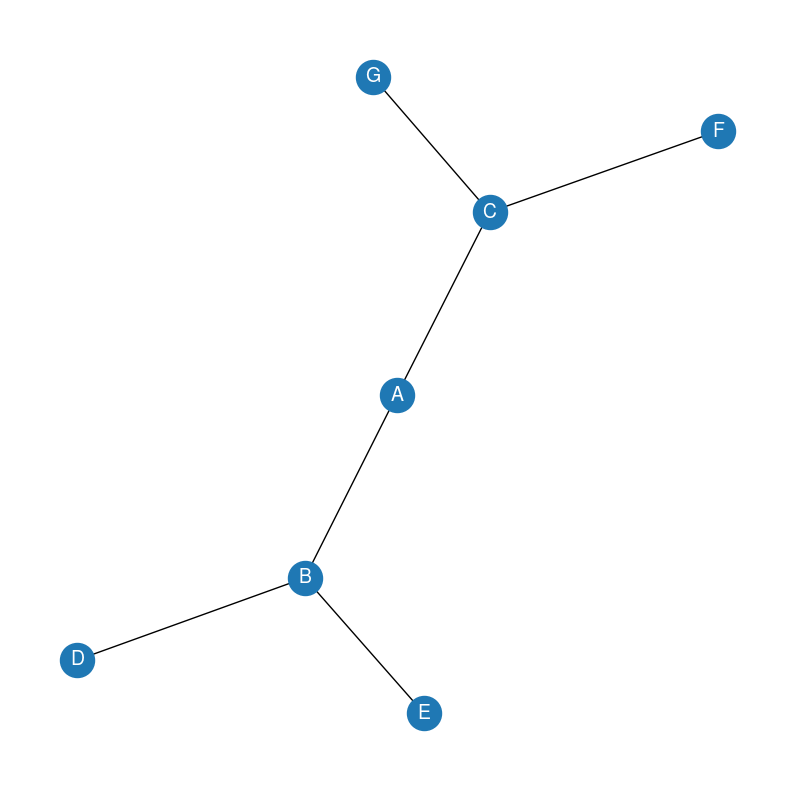

In [48]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()
G.add_edges_from([('A', 'B'), ('A', 'C'), ('B', 'D'), ('B', 'E'), ('C', 'F'), ('C', 'G')])

plt.axis('off')
nx.draw_networkx(G,
                 pos=nx.spring_layout(G, seed=1),
                 node_size=600,
                 cmap='coolwarm',
                 font_size=14,
                 font_color='white'
                 )

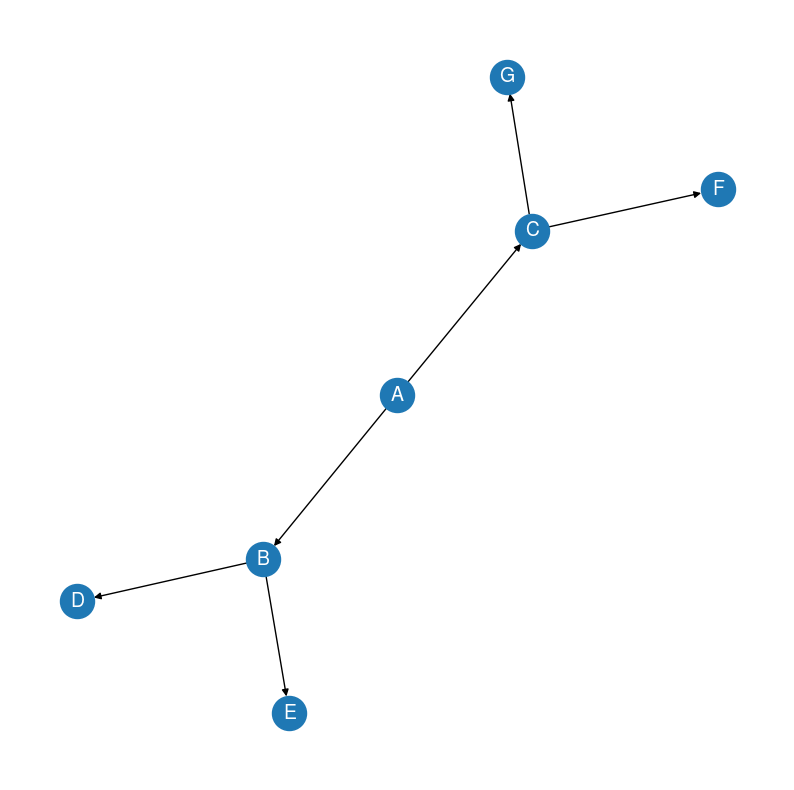

In [50]:
DG = nx.DiGraph()
DG.add_edges_from([('A','B'),('A','C'),('B','D'),('B','E'),('C','F'),('C','G')])
plt.axis('off')
nx.draw_networkx(DG, pos=nx.spring_layout(G,seed=0),
                node_size = 600,
                cmap='coolwarm',
                font_size =14,
                font_color ='white'
                )

{('A', 'B'): Text(-0.1706315198741737, -0.2578552365595852, '10'),
 ('A', 'C'): Text(0.16908356984222794, 0.25842480777820764, '20'),
 ('B', 'D'): Text(-0.5751308102372683, -0.581911163880947, '30'),
 ('B', 'E'): Text(-0.30708667522372135, -0.7577133164384281, '40'),
 ('C', 'F'): Text(0.5743062218253918, 0.581523985503456, '50'),
 ('C', 'G'): Text(0.3081454345659025, 0.7583011910514879, '60')}

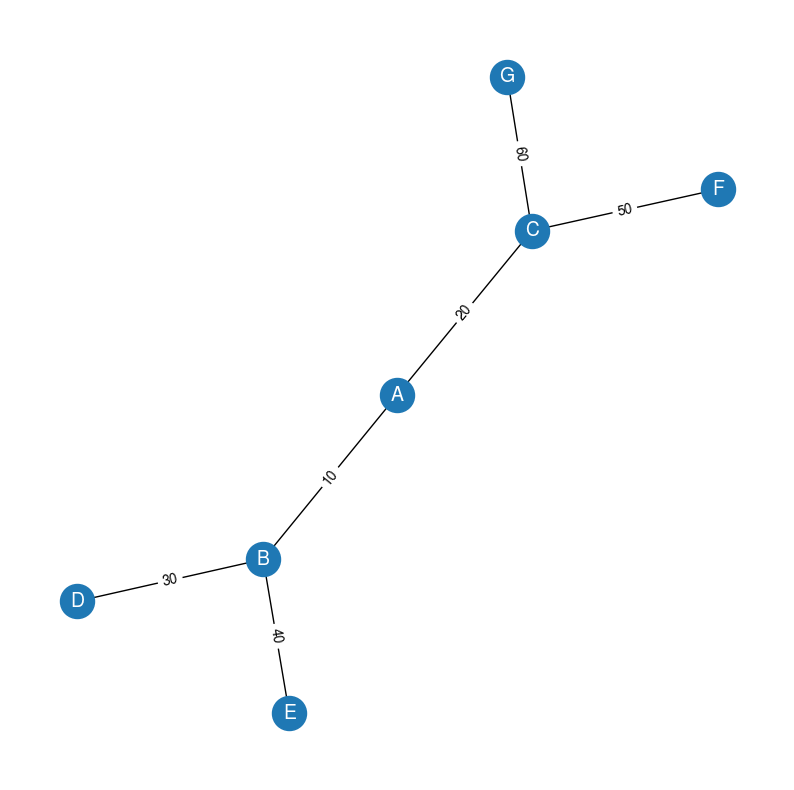

In [53]:
WG = nx.Graph()
WG.add_edges_from([('A', 'B', {"weight": 10}), ('A', 'C', {"weight": 20}), ('B', 'D', {"weight": 30}), ('B', 'E', {"weight": 40}), ('C', 'F', {"weight": 50}), ('C', 'G', {"weight": 60})])
labels = nx.get_edge_attributes(WG,"weight")
plt.axis('off')
nx.draw_networkx(WG,
                 pos=nx.spring_layout(G, seed=0),
                 node_size=600,
                 cmap='coolwarm',
                 font_size=14,
                 font_color='white'
                 )
nx.draw_networkx_edge_labels(WG, pos=nx.spring_layout(G, seed=0), edge_labels=labels)

Is graph 1 connected? False


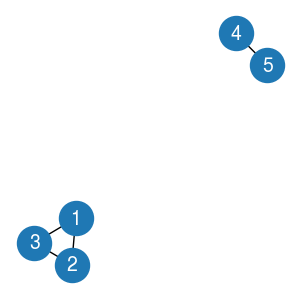

In [57]:
G1 = nx.Graph()
G1.add_edges_from([(1,2),(2,3),(3,1),(4,5)])
print(f"Is graph 1 connected? {nx.is_connected(G1)}")
plt.figure(figsize=(8,8))
plt.subplot(221)
plt.axis('off')
nx.draw_networkx(G1,
                 pos=nx.spring_layout(G1, seed =0),
                node_size=600,
                cmap='coolwarm',
                font_size =14,
                font_color='white')

Is graph 2 conntected? True


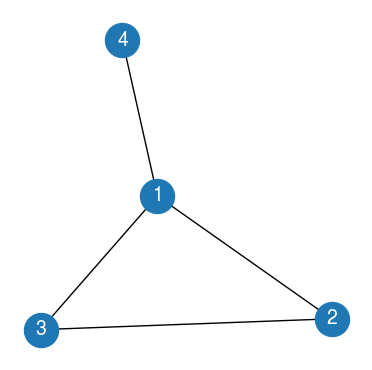

In [61]:
G2 = nx.Graph()
G2.add_edges_from([(1,2),(2,3),(3,1),(1,4)])
print(f"Is graph 2 conntected? {nx.is_connected(G2)}")
plt.subplot(222)
plt.axis('off')
nx.draw_networkx(G2,
                pos=nx.spring_layout(G2,seed =0),
                node_size = 600,
                cmap= 'coolwarm',
                font_size=14,
                font_color='white')

deg(A) = 2
Is graph 2 conntected? True


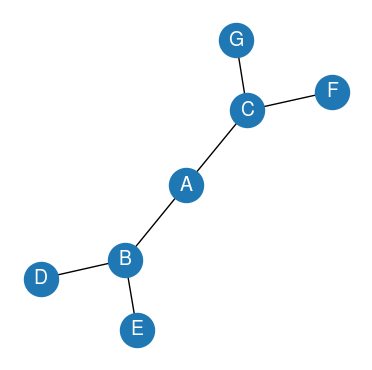

In [65]:
G = nx.Graph()
G.add_edges_from([('A','B'),('A','C'),('B','D'),('B','E'),('C','F'),('C','G')])
print(f"deg(A) = {G.degree['A']}")
print(f"Is graph 2 conntected? {nx.is_connected(G2)}")
plt.subplot(222)
plt.axis('off')
nx.draw_networkx(G,
                pos=nx.spring_layout(G,seed =0),
                node_size = 600,
                cmap= 'coolwarm',
                font_size=14,
                font_color='white')

deg^-(A) = 0
deg^+(A) = 2
Is graph 2 conntected? True


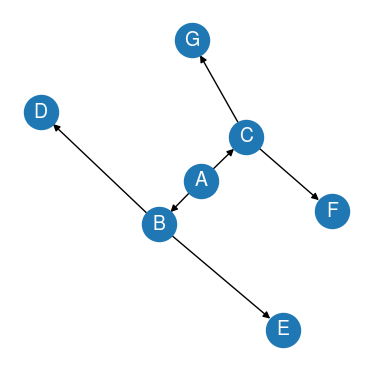

In [66]:
DG = nx.DiGraph()
DG.add_edges_from([('A', 'B'), ('A', 'C'), ('B', 'D'), ('B', 'E'), ('C', 'F'), ('C', 'G')])
print(f"deg^-(A) = {DG.in_degree['A']}")
print(f"deg^+(A) = {DG.out_degree['A']}")
print(f"Is graph 2 conntected? {nx.is_connected(G2)}")
plt.subplot(222)
plt.axis('off')
nx.draw_networkx(DG,
                pos=nx.spring_layout(DG,seed =0),
                node_size = 600,
                cmap= 'coolwarm',
                font_size=14,
                font_color='white')

In [68]:
print(f"Degree centrality = {nx.degree_centrality(G)}")


Degree centrality = {'A': 0.3333333333333333, 'B': 0.5, 'C': 0.5, 'D': 0.16666666666666666, 'E': 0.16666666666666666, 'F': 0.16666666666666666, 'G': 0.16666666666666666}


In [69]:
print(f"Closeness centrality = {nx.closeness_centrality(G)}")

Closeness centrality = {'A': 0.6, 'B': 0.5454545454545454, 'C': 0.5454545454545454, 'D': 0.375, 'E': 0.375, 'F': 0.375, 'G': 0.375}


In [70]:
print(f"Betweenness centrality = {nx.betweenness_centrality(G)}")


Betweenness centrality = {'A': 0.6, 'B': 0.6, 'C': 0.6, 'D': 0.0, 'E': 0.0, 'F': 0.0, 'G': 0.0}
